# Taller de Python — Clase 6: Costo Computacional y Pensamiento Algorítmico

En clases anteriores dominamos las herramientas fundamentales de Python: estructuras de datos (listas, diccionarios), funciones y control de flujo. Hasta ahora, nuestro objetivo principal ha sido lograr que el código *funcione*. Hoy daremos un paso más allá: haremos que el código sea *eficiente*.

Como economistas, ustedes ya son expertos en analizar la eficiencia. Piensen en un algoritmo (un bloque de código que resuelve un problema) como una **función de producción**. Los *inputs* son nuestros datos, el *output* es el resultado deseado, y los *costos* son el tiempo de procesamiento y la memoria de la computadora. Al igual que en una fábrica, podemos producir el mismo bien utilizando una tecnología obsoleta y costosa, o una tecnología moderna y optimizada.

> **¿Por qué importa esto?**
> ¿Por qué un script puede tardar 2 segundos en procesar un millón de transacciones, mientras que otro script, escrito para hacer *exactamente lo mismo*, tarda 5 horas y congela la computadora?

La respuesta casi nunca está en comprar una computadora más cara (aumentar el capital), sino en cambiar la lógica subyacente del código (mejorar la tecnología). A esta capacidad de estructurar soluciones eficientes le llamamos **Pensamiento Algorítmico**.

### Hoja de Ruta de la Clase

En esta sesión conectaremos sus intuiciones económicas sobre funciones de costos con el diseño de software. Nuestro recorrido será el siguiente:

1. **Motivación:** Veremos empíricamente cómo una pequeña decisión de diseño cambia radicalmente el tiempo de ejecución frente a un problema de datos.
2. **Complejidad como Función de Costos:** Introduciremos la notación "Big O", el estándar para medir la eficiencia, apoyándonos en analogías económicas.
3. **Catálogo de Transformaciones:** Aprenderemos patrones concretos para transformar código lento en código rápido (limpieza de loops, Divide y Vencerás, Memoización).
4. **Ejercicios Prácticos y Tradeoffs:** Diagnosticaremos código ineficiente y discutiremos cuándo vale la pena optimizar.
5. **Ejercicio Integrador** Auditaremos y optimizaremos un proceso de reporte financiero completo.

## Parte 1: Motivación

Imagina que estás auditando los registros de un banco comercial. Te entregan una base de datos con miles de transacciones diarias y tu tarea es simple: **encontrar si hay transacciones duplicadas** (es decir, el mismo ID de transacción registrado más de una vez por error del sistema).

Para entender esto, hagamos una analogía con el mundo físico. Imagina que tienes una pila de 30,000 facturas impresas en tu escritorio y necesitas encontrar las duplicadas. 

*   **El enfoque ingenuo (Fuerza Bruta):** Tomas la primera factura y la comparas con las 29,999 restantes. Luego tomas la segunda y la comparas con las 29,998 restantes. Y así sucesivamente. Es un proceso exhaustivo, seguro, pero increíblemente lento.
*   **El enfoque inteligente (Uso de Memoria/Índices):** A medida que lees cada factura, la archivas en carpetas ordenadas alfabéticamente o anotas su número en una libreta. Si al tomar una factura nueva ves que ese número ya está en tu libreta, ¡encontraste un duplicado al instante!

En programación, estas decisiones de diseño dictan el **costo computacional** de nuestro código. Existen dos reglas fundamentales que guiarán nuestra intuición económica hoy:

*   **El tiempo es escaso:** Queremos minimizar el número de operaciones (pasos) que la computadora debe realizar.
*   **El espacio tiene un costo:** Podemos usar estructuras de datos adicionales (como diccionarios) para "recordar" información y ahorrar tiempo, pero esto consumirá más memoria RAM.

Vamos a demostrar empíricamente la diferencia abismal entre estos dos enfoques utilizando Python.

In [1]:
import time
import random

# 1. Generamos un dataset simulado de 30,000 transacciones bancarias (IDs únicos)
transacciones = list(range(1, 30001))

# Inyectamos intencionalmente 3 transacciones duplicadas para que nuestro código las encuentre
transacciones.extend([1505, 8999, 25000])

# Mezclamos la lista para simular el orden aleatorio de llegada en un sistema real
random.shuffle(transacciones)

def buscar_duplicados_fuerza_bruta(lista_tx):
    """
    Busca transacciones duplicadas comparando cada elemento con todos los demás.
    Simula el enfoque de 'tomar una factura y compararla con el resto del cerro'.
    
    Parámetros:
    lista_tx (list): Lista de IDs de transacciones.
    
    Retorna:
    list: Lista con los IDs duplicados encontrados.
    """
    duplicados = []
    n = len(lista_tx)
    
    # Un loop dentro de otro loop (Nested Loop)
    for i in range(n):
        # Por qué (i + 1)? Pues porque ya hicimos la comparación con todos los índices anteriores
        for j in range(i + 1, n):
            if lista_tx[i] == lista_tx[j]:
                if lista_tx[i] not in duplicados:
                    duplicados.append(lista_tx[i])
                    
    return duplicados

print("Iniciando búsqueda por Fuerza Bruta (esto puede tomar unos segundos)...")
inicio_fb = time.time()
resultado_fb = buscar_duplicados_fuerza_bruta(transacciones)
fin_fb = time.time()

tiempo_fb = fin_fb - inicio_fb
print(f"Duplicados encontrados: {resultado_fb}")
print(f"Tiempo de ejecución (Fuerza Bruta): {tiempo_fb:.4f} segundos")

Iniciando búsqueda por Fuerza Bruta (esto puede tomar unos segundos)...
Duplicados encontrados: [25000, 8999, 1505]
Tiempo de ejecución (Fuerza Bruta): 7.6716 segundos


In [2]:
def buscar_duplicados_diccionario(lista_tx):
    """
    Busca transacciones duplicadas utilizando un diccionario como 'libreta de registro'
    para recordar los IDs que ya hemos visto en una sola pasada.
    
    Parámetros:
    lista_tx (list): Lista de IDs de transacciones.
    
    Retorna:
    list: Lista con los IDs duplicados encontrados.
    """
    vistos = {}  # Nuestro diccionario que actuará como índice/memoria
    duplicados = []
    
    # Un solo loop (Una sola pasada por los datos)
    for tx in lista_tx:
        # Buscar en un diccionario es una operación casi instantánea en Python
        if tx in vistos:
            if tx not in duplicados:
                duplicados.append(tx)
        else:
            # Si no lo hemos visto, lo registramos en nuestra 'libreta'
            vistos[tx] = True
            
    return duplicados

print("Iniciando búsqueda con Diccionario...")
inicio_dicc = time.time()
resultado_dicc = buscar_duplicados_diccionario(transacciones)
fin_dicc = time.time()

tiempo_dicc = fin_dicc - inicio_dicc
print(f"Duplicados encontrados: {resultado_dicc}")
print(f"Tiempo de ejecución (Diccionario): {tiempo_dicc:.6f} segundos")

# Calculemos cuántas veces más rápido es el enfoque B
multiplo = tiempo_fb / tiempo_dicc if tiempo_dicc > 0 else float('inf')
print(f"\n¡La Versión B fue {multiplo:.0f} veces más rápida!")

Iniciando búsqueda con Diccionario...
Duplicados encontrados: [8999, 1505, 25000]
Tiempo de ejecución (Diccionario): 0.001583 segundos

¡La Versión B fue 4846 veces más rápida!


### El Trade-off Fundamental: Espacio vs. Tiempo

¿Qué acaba de pasar? Acabamos de presenciar cómo un cambio en la lógica del algoritmo reduce el tiempo de ejecución de varios segundos a una fracción de milisegundo. En un entorno real con millones de registros, la Versión A (Fuerza Bruta) podría tardar **días** en terminar, mientras que la Versión B terminaría en **segundos**.

Veamos la comparación estructural de nuestra "función de producción":

| Característica | Versión A (Fuerza Bruta) | Versión B (Diccionario) |
| :--- | :--- | :--- |
| **Estructura** | Loop anidado (`for` dentro de `for`) | Loop simple + Diccionario |
| **Operaciones (aprox)** | $30,000 \times 30,000 / 2 \approx 450$ millones | $30,000$ (una sola pasada) |
| **Costo de Tiempo** | Altísimo (Crece exponencialmente) | Mínimo (Crece linealmente) |
| **Costo de Memoria** | Mínimo (No guarda nada extra) | Mayor (Guarda 30,000 llaves en el diccionario) |

Aquí es donde entra su intuición económica sobre los **trade-offs** (costos de oportunidad):

*   **Intercambiamos Espacio por Velocidad:** Para lograr que el código fuera miles de veces más rápido, tuvimos que "pagar" el costo de crear un diccionario (`vistos = {}`) que ocupa memoria RAM en la computadora.
*   **El Capital es barato, el Tiempo es caro:** En la computación moderna, la memoria RAM es relativamente abundante y barata. El tiempo de procesamiento (y el tiempo del analista esperando frente a la pantalla) es el recurso verdaderamente escaso. Por lo tanto, casi siempre preferiremos algoritmos que consuman un poco más de memoria si a cambio nos devuelven resultados instantáneos.

### ¿Por qué el diccionario es mágico?

Para entender por qué la Versión B es tan rápida, debemos entender cómo Python maneja los diccionarios por debajo. 

> **Analogía:** Buscar un elemento en una lista es como buscar una palabra leyendo un libro página por página. Buscar una llave en un diccionario es como ir **directamente al índice alfabético** al final del libro: saltas directamente a la respuesta.

Imagina que nuestra lista de transacciones es pequeña: `[101, 205, 101]`.

**Paso a paso (Traza Visual de la Versión B):**

1.  **Iteración 1:** `tx = 101`
    *   ¿Está `101` en el diccionario `vistos`? No. 
    *   *Acción:* Lo agregamos. Estado de la memoria: `vistos = {101: True}`
2.  **Iteración 2:** `tx = 205`
    *   ¿Está `205` en `vistos`? No.
    *   *Acción:* Lo agregamos. Estado de la memoria: `vistos = {101: True, 205: True}`
3.  **Iteración 3:** `tx = 101`
    *   ¿Está `101` en `vistos`? **¡SÍ!** (Python lo sabe instantáneamente gracias a una técnica matemática llamada *Hashing*).
    *   *Acción:* Lo marcamos como duplicado.

Al eliminar el loop interno, transformamos un problema multiplicativo ($N \times N$) en un problema aditivo ($N$). En la siguiente sección, formalizaremos esta intuición matemática utilizando la notación estándar de la industria.

<div style="background: linear-gradient(135deg, #1a1a2e 0%, #16213e 50%, #0f3460 100%); border-left: 4px solid #e94560; border-radius: 8px; padding: 24px 28px; margin: 20px 0; color: #e0e0e0; font-size: 14.5px; line-height: 1.75;">

<h4 style="color: #e94560; margin-top: 0;">🔬 Para los curiosos: ¿Qué es realmente una Hash Function?</h4>

<p>Una <b style="color: #ffffff;">hash function</b> es una función matemática que recibe cualquier dato — un string, un número, un archivo entero — y lo transforma en un <b style="color: #ffffff;">índice numérico</b> de tamaño fijo. Ese índice le dice a Python <i>exactamente</i> en qué posición de memoria guardar y buscar el valor, sin recorrer nada.</p>

<p>Piénsalo así. Quieres saber si <b>Patricia</b> vive en un edificio de 1,000 apartamentos:</p>

<table style="width: 100%; border-collapse: collapse; margin: 12px 0;">
<tr>
<td style="padding: 10px 14px; border: 1px solid #334; background: #1f2937; width: 50%;"><b style="color: #f87171;">Lista (sin hash)</b><br>Tocas la puerta del apto 1, luego el 2, luego el 3... hasta encontrarla. Si vive en el 847, tocaste 847 puertas.</td>
<td style="padding: 10px 14px; border: 1px solid #334; background: #1f2937; width: 50%;"><b style="color: #34d399;">Diccionario (con hash)</b><br>Calculas <code style="color: #fbbf24;">hash("patricia") → 847</code>. Vas directo al apartamento 847. Una sola puerta, siempre.</td>
</tr>
</table>

<p>La llave <i>misma</i> contiene la dirección. No se busca en un índice — <b style="color: #ffffff;">la llave se convierte en el índice</b>.</p>

<h4 style="color: #e94560;">Propiedades de una buena hash function</h4>
<ul style="margin: 4px 0;">
<li><b style="color: #ffffff;">Determinista:</b> la misma entrada <i>siempre</i> produce el mismo número. <code style="color: #fbbf24;">hash("patricia")</code> hoy, mañana y siempre da lo mismo.</li>
<li><b style="color: #ffffff;">Distribución uniforme:</b> reparte las llaves de forma pareja por toda la tabla, evitando que todos caigan en el mismo casillero.</li>
<li><b style="color: #ffffff;">Eficiente:</b> calcular el hash toma tiempo constante, sin importar el tamaño de la tabla.</li>
<li><b style="color: #ffffff;">Irreversible (en las criptográficas):</b> dado el resultado, es prácticamente imposible reconstruir la entrada original.</li>
</ul>

<h4 style="color: #e94560;">Más allá de Python: la ciencia detrás de hashing</h4>

<p>Algoritmos como <b style="color: #ffffff;">SHA-256</b> (Secure Hash Algorithm, 256 bits) llevan esta misma idea a otro nivel. SHA-256 toma cualquier dato y produce una huella digital única de 64 caracteres hexadecimales. Esta es la base de tecnologías que usamos todos los días:</p>

<ul style="margin: 4px 0;">
<li><b style="color: #ffffff;">Criptomonedas:</b> Bitcoin funciona porque los mineros compiten por encontrar un input cuyo SHA-256 cumpla ciertas condiciones. Toda la blockchain es una cadena de hashes que garantiza que nadie pueda alterar una transacción pasada.</li>
<li><b style="color: #ffffff;">Contraseñas:</b> los sistemas seguros nunca guardan tu contraseña — guardan su hash. Cuando inicias sesión, comparan <code style="color: #fbbf24;">hash(lo_que_escribiste)</code> contra el hash almacenado. Si alguien roba la base de datos, solo ve hashes irreversibles.</li>
<li><b style="color: #ffffff;">Integridad de archivos:</b> cuando descargas un software, puedes verificar su hash SHA-256 contra el publicado por el autor. Si un solo byte fue alterado, el hash cambia completamente — así sabes si el archivo fue dañado o manipulado.</li>
</ul>

<p style="margin-bottom: 0; color: #9ca3af; font-style: italic;">En resumen: el hashing es una de las ideas más elegantes de la computación. En Python nos regala diccionarios en O(1); en el mundo real, sostiene la seguridad digital moderna.</p>

</div>

## Parte 2: Complejidad como Función de Costos

En economía, utilizamos funciones de producción para modelar cómo los insumos se transforman en productos. Una de las más conocidas es la función Cobb-Douglas: $Y = A K^\alpha L^\beta$. Esta ecuación nos permite entender los rendimientos a escala de nuestra fábrica.

En ciencias de la computación, hacemos exactamente lo mismo con nuestros algoritmos, pero nuestra "función de producción" se enfoca en los **costos**. Definimos una función $T(n)$, donde:
*   **$T$** es el tiempo de ejecución (o el número de operaciones elementales).
*   **$n$** es el tamaño del *input* (por ejemplo, el número de filas en nuestro DataFrame o elementos en una lista).

Para estandarizar cómo hablamos de $T(n)$, la industria utiliza la **Notación Big O** (O mayúscula). 

### Big O y el Value at Risk (VaR)

Si han estudiado finanzas, conocerán el *Value at Risk* (VaR). El VaR nos da una cota: "En el peor 1% de los escenarios, mi portafolio perderá como máximo $X millones". 

La notación **Big O** es el equivalente computacional del VaR. Nos da una **cota superior asintótica** (upper bound). Nos dice: "A medida que el tamaño de los datos ($n$) crece hacia el infinito, el número de operaciones que hará este código crecerá, en el peor de los casos, a una tasa proporcional a $O(f(n))$".

Aquí tienen un diccionario de traducción entre nuestros conceptos económicos y el diseño de software:

| Concepto Económico / Estadístico | Concepto Computacional | Explicación Práctica |
| :--- | :--- | :--- |
| Tamaño de la Muestra ($N$) | Tamaño del Input ($n$) | Cantidad de datos a procesar (ej. 1 millón de transacciones). |
| Función de Costos | $T(n)$ | Ecuación exacta de cuántos pasos toma el algoritmo. |
| Cota Superior (Worst-case) | Notación Big O ($O(\cdot)$) | Comportamiento del costo cuando $n$ tiende a infinito. |
| Rendimientos Constantes | Complejidad Lineal $O(n)$ | Si duplico los datos, el tiempo de ejecución se duplica. |
| Rendimientos Decrecientes | Complejidad Cuadrática $O(n^2)$ | Si duplico los datos, el tiempo se multiplica por 4 (¡Peligro!). |

### Sintaxis de la Notación

Cuando hablamos con otros analistas o ingenieros de datos, utilizamos esta sintaxis estándar:

```text
O(n)   -> Se lee como "Orden N" o "Complejidad Lineal"
O(1)   -> Se lee como "Orden 1" o "Tiempo Constante"
O(n^2) -> Se lee como "Orden N cuadrada" o "Complejidad Cuadrática"
```

Vamos a visualizar gráficamente cómo se ven estas "funciones de costos" a medida que aumentamos el tamaño de nuestros datos.

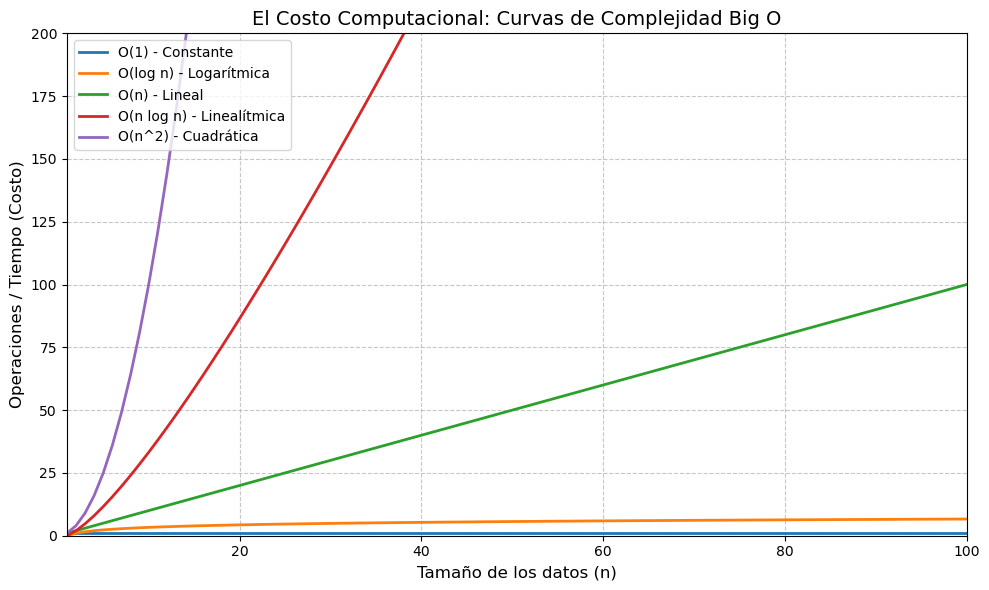

In [3]:
import matplotlib.pyplot as plt
import math

def graficar_curvas_complejidad():
    """
    Genera un gráfico comparativo de las funciones de complejidad Big O más comunes.
    Demuestra visualmente por qué los algoritmos O(n^2) 'explotan' rápidamente
    a medida que aumenta el tamaño de los datos (n).
    """
    # Tamaños de input (n) del 1 al 100
    n = list(range(1, 101))
    
    # Calculamos el 'costo' (número de operaciones) para cada tipo de complejidad
    o_1 = [1 for _ in n]                           # O(1) - Constante
    o_log_n = [math.log(x, 2) for x in n]          # O(log n) - Logarítmica
    o_n = [x for x in n]                           # O(n) - Lineal
    o_n_log_n = [x * math.log(x, 2) for x in n]    # O(n log n) - Linealítmica
    o_n_cuadrado = [x**2 for x in n]               # O(n^2) - Cuadrática
    
    # Configuración del gráfico
    plt.figure(figsize=(10, 6))
    plt.plot(n, o_1, label='O(1) - Constante', linewidth=2)
    plt.plot(n, o_log_n, label='O(log n) - Logarítmica', linewidth=2)
    plt.plot(n, o_n, label='O(n) - Lineal', linewidth=2)
    plt.plot(n, o_n_log_n, label='O(n log n) - Linealítmica', linewidth=2)
    plt.plot(n, o_n_cuadrado, label='O(n^2) - Cuadrática', linewidth=2)
    
    # Limitamos el eje Y para poder ver las curvas inferiores antes de que n^2 explote
    plt.ylim(0, 200)
    plt.xlim(1, 100)
    
    plt.title('El Costo Computacional: Curvas de Complejidad Big O', fontsize=14)
    plt.xlabel('Tamaño de los datos (n)', fontsize=12)
    plt.ylabel('Operaciones / Tiempo (Costo)', fontsize=12)
    plt.legend(loc='upper left')
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

# Ejecutamos la función para ver el gráfico
graficar_curvas_complejidad()

### El Vocabulario Mínimo de Big O

Como economistas que programan, no necesitan memorizar demostraciones matemáticas complejas. Solo necesitan reconocer los **patrones de código** que generan estas curvas. Aquí está el vocabulario esencial:

*   **$O(1)$ - Constante:** El Santo Grial. No importa si tienes 10 datos o 10 millones, el tiempo es el mismo. 
    *   *Patrón:* Acceder a un valor en un diccionario por su llave, o a una lista por su índice.
*   **$O(\log n)$ - Logarítmica:** Extremadamente eficiente. El costo crece muy lento porque el algoritmo descarta la mitad de los datos en cada paso.
    *   *Patrón:* Búsqueda binaria (buscar una palabra en un diccionario físico abriéndolo por la mitad).
*   **$O(n)$ - Lineal:** El estándar aceptable. El costo crece proporcionalmente a los datos.
    *   *Patrón:* Un loop `for` simple que recorre una lista (una sola pasada).
*   **$O(n \log n)$ - Linealítmica:** El límite de eficiencia para ordenar datos.
    *   *Patrón:* Algoritmos de ordenamiento optimizados (como el que usa Python internamente cuando llamas a `sorted()`).
*   **$O(n^2)$ - Cuadrática:** El cuello de botella. Aceptable para 1,000 datos, catastrófico para 1 millón.
    *   *Patrón:* Loops anidados (un `for` dentro de otro `for`).

Visualmente en código, la diferencia estructural es evidente:

```python
# Patrón O(n) - Costo Lineal (Una pasada)
for cliente in base_datos:
    enviar_correo(cliente)

# Patrón O(n^2) - Costo Cuadrático (Todos contra todos)
for cliente_a in base_datos:
    for cliente_b in base_datos:
        calcular_similitud(cliente_a, cliente_b)
```

> **Recuerda:** En Big O, **ignoramos las constantes**. Si tu código tiene dos loops separados (uno después del otro), el costo es $O(n) + O(n) = O(2n)$. Sin embargo, en Big O esto se simplifica a $O(n)$. ¿Por qué? Porque cuando $n$ tiende a infinito (ej. un billón de datos), multiplicar por 2 es irrelevante comparado con la diferencia entre una curva lineal y una cuadrática ($n^2$). ¡Solo nos importa la forma de la curva!

In [4]:
# Ejemplos de O(1) y O(n) en un contexto financiero

# Simulamos un portafolio de inversiones usando un diccionario
portafolio_precios = {
    'AAPL': 150.50,
    'MSFT': 310.20,
    'GOOGL': 2750.00,
    'AMZN': 3300.80,
    'TSLA': 700.40
}

def obtener_precio_o1(portafolio, ticker):
    """
    Obtiene el precio de un activo específico.
    Complejidad: O(1) - Tiempo Constante.
    Python usa una función 'hash' para ir directamente a la ubicación en memoria.
    
    Parámetros:
    portafolio (dict): Diccionario con tickers y precios.
    ticker (str): Símbolo del activo a buscar.
    
    Retorna:
    float o str: El precio del activo o un mensaje de error.
    """
    # No hay loops. Es una operación directa.
    return portafolio.get(ticker, "Activo no encontrado")

def calcular_total_on(portafolio):
    """
    Calcula el valor total asumiendo 1 acción de cada activo.
    Complejidad: O(n) - Tiempo Lineal.
    El tiempo de ejecución dependerá directamente de cuántos activos haya.
    
    Parámetros:
    portafolio (dict): Diccionario con tickers y precios.
    
    Retorna:
    float: La suma total de los precios.
    """
    total = 0.0
    # Un loop simple. Si hay N activos, hace N sumas.
    for precio in portafolio.values():
        total += precio
    return total

# Demostración
precio_apple = obtener_precio_o1(portafolio_precios, 'AAPL')
valor_total = calcular_total_on(portafolio_precios)

print(f"Precio de AAPL (Operación O(1)): ${precio_apple}")
print(f"Valor total del portafolio (Operación O(n)): ${valor_total:.2f}")

Precio de AAPL (Operación O(1)): $150.5
Valor total del portafolio (Operación O(n)): $7211.90


In [5]:
# Ejemplo de O(n^2) - El peligro de los loops anidados

activos = ['AAPL', 'MSFT', 'GOOGL', 'AMZN']

def comparar_pares_on2(lista_activos):
    """
    Genera todas las combinaciones únicas de pares de activos.
    Este es el primer paso clásico si quisiéramos calcular una matriz 
    de varianzas-covarianzas o correlaciones desde cero.
    
    Complejidad: O(n^2) - Tiempo Cuadrático.
    Por cada activo, iteramos sobre el resto de los activos.
    
    Parámetros:
    lista_activos (list): Lista de símbolos de activos.
    
    Retorna:
    list: Lista de tuplas con los pares únicos.
    """
    pares = []
    n = len(lista_activos)
    
    # Loop externo
    for i in range(n):
        # Loop interno: nota cómo depende del loop externo (i + 1)
        for j in range(i + 1, n):
            par = (lista_activos[i], lista_activos[j])
            pares.append(par)
            
    return pares

# Demostración
pares_generados = comparar_pares_on2(activos)

print(f"Para {len(activos)} activos, se generaron {len(pares_generados)} pares a comparar:")
for par in pares_generados:
    print(f" - Comparando {par[0]} con {par[1]}")
    
# Reflexión: Si tuviéramos los 500 activos del S&P 500, 
# este código haría (500 * 499) / 2 = 124,750 iteraciones.

Para 4 activos, se generaron 6 pares a comparar:
 - Comparando AAPL con MSFT
 - Comparando AAPL con GOOGL
 - Comparando AAPL con AMZN
 - Comparando MSFT con GOOGL
 - Comparando MSFT con AMZN
 - Comparando GOOGL con AMZN


<style>
.sigma-block { display: inline-flex; align-items: center; gap: 4px; margin: 0 4px; }
.sigma-sym { display: inline-flex; flex-direction: column; align-items: center; line-height: 1.1; }
.sigma-sym .top { font-size: 11px; color: #9ca3af; }
.sigma-sym .sym { font-size: 26px; color: #ffffff; }
.sigma-sym .bot { font-size: 11px; color: #9ca3af; }
.math-line { text-align: center; font-size: 17px; color: #ffffff; margin: 16px 0; }
</style>

<div style="background: linear-gradient(135deg, #1a1a2e 0%, #16213e 50%, #0f3460 100%); border-left: 4px solid #e94560; border-radius: 8px; padding: 24px 28px; margin: 20px 0; color: #e0e0e0; font-size: 14.5px; line-height: 1.75;">

<h4 style="color: #e94560; margin-top: 0;">🔬 Para los curiosos: ¿Por qué O(n²) y no n(n−i)?</h4>

<p>Si miraste el código con atención, notaste algo: el loop interno <b style="color: #ffffff;">no recorre todos los elementos</b>. Empieza en <code style="color: #fbbf24;">i + 1</code>, así que cada iteración hace menos trabajo que la anterior. Entonces, ¿por qué decimos que es O(n²) y no algo menor? La respuesta está en la diferencia entre <b style="color: #ffffff;">contar pasos exactos</b> y <b style="color: #ffffff;">describir cómo crece el costo</b>.</p>

<h4 style="color: #e94560;">1. El conteo real</h4>

<p>Si sumamos cuántas veces ocurre la operación dentro del bucle, estamos sumando los números desde <i>n−1</i> hasta 1. Matemáticamente, esto es:</p>

</div>


$$\sum_{i=0}^{n-1} (n - 1 - i) = (n-1) + (n-2) + \dots + 1 = \frac{n(n-1)}{2}$$


<div style="background: linear-gradient(135deg, #1a1a2e 0%, #16213e 50%, #0f3460 100%); border-left: 4px solid #e94560; border-radius: 8px; padding: 24px 28px; margin: 20px 0; color: #e0e0e0; font-size: 14.5px; line-height: 1.75;">

<h4 style="color: #e94560;">2. La expansión algebraica</h4>

<p>Si expandimos esa fórmula:</p>

$$\frac{n(n-1)}{2} = \frac{n^2 - n}{2} = \frac{1}{2}n^2 - \frac{1}{2}$$

<div style="background: linear-gradient(135deg, #1a1a2e 0%, #16213e 50%, #0f3460 100%); border-left: 4px solid #e94560; border-radius: 8px; padding: 24px 28px; margin: 20px 0; color: #e0e0e0; font-size: 14.5px; line-height: 1.75;">

<h4 style="color: #e94560;">3. La "magia" de la notación Big O</h4>

<p>Big O no busca el número exacto de operaciones — busca describir <b style="color: #ffffff;">qué tan rápido crece el costo cuando n tiende al infinito</b>. Para eso aplica dos reglas de oro:</p>

<ul style="margin: 4px 0;">
<li><b style="color: #ffffff;">Ignoramos las constantes:</b> ½n² crece igual que n². El ½ no cambia la forma de la curva, solo la escala.</li>
<li><b style="color: #ffffff;">Ignoramos los términos de menor orden:</b> entre n² y n, el término cuadrático crece mucho más rápido. Si n = 1,000,000 tienes n² = 10¹² vs. n = 10⁶. En el límite, el −½n se vuelve irrelevante.</li>
</ul>

<p>Por lo tanto:</p>

<div class="math-line">
  ½n²
  &nbsp;−&nbsp;
  ½n
  &nbsp; ⟶ &nbsp;
  <b style="color: #34d399; font-size: 19px;">O(n²)</b>
</div>

<h4 style="color: #e94560;">4. Visualización: el triángulo dentro del cuadrado</h4>

<p>Imagina una matriz de n × n. Un doble loop completo (<code style="color: #fbbf24;">range(n)</code> × <code style="color: #fbbf24;">range(n)</code>) recorre <i>toda</i> la matriz: n² celdas. Nuestro código, con <code style="color: #fbbf24;">range(i+1, n)</code>, recorre solo el <b style="color: #ffffff;">triángulo superior</b> — exactamente la mitad. Pero la mitad de n² sigue siendo proporcional a n². Si duplicas n, el triángulo se cuadruplica, no se duplica. El crecimiento es cuadrático.</p>

<table style="width: 100%; border-collapse: collapse; margin: 12px 0;">
<tr>
<td style="padding: 10px 14px; border: 1px solid #334; background: #1f2937; text-align: center; width: 50%;"><b style="color: #f87171;">Operaciones exactas</b><br><br><span style="font-size: 17px; color: #ffffff;">(n² − n) / 2</span></td>
<td style="padding: 10px 14px; border: 1px solid #334; background: #1f2937; text-align: center; width: 50%;"><b style="color: #34d399;">Notación Big O</b><br><br><span style="font-size: 17px; color: #ffffff;">O(n²)</span></td>
</tr>
</table>

<p style="margin-bottom: 0; color: #9ca3af; font-style: italic;">En resumen: No son exactamente n² pasos. Pero Big O es una herramienta de <b>clasificación</b>, no de conteo. Así como en economía decimos que una función de costos es "cuadrática" sin importar si el coeficiente líder es ½ o 3, Big O clasifica este algoritmo como cuadrático porque su costo crece proporcionalmente al cuadrado de n.

</div>

## Parte 3: Catálogo de Transformaciones

Ya sabemos cómo diagnosticar el costo de un algoritmo usando la notación Big O. Ahora, pasaremos a la acción. En esta sección construiremos un **catálogo de transformaciones**: patrones de diseño que nos permiten tomar un código ineficiente y reescribirlo para que sea radicalmente más rápido.


### Transformación 1: Limpieza de Loops (Sacar la Basura)

La transformación más común y fácil de aplicar en el día a día de un analista de datos es limpiar los loops. Un loop multiplica el costo computacional de todo lo que pongas dentro de él. Si pones una operación pesada dentro de un loop de 1 millón de iteraciones, esa operación se ejecutará 1 millón de veces.

> **Recuerda:** ¡Nunca calcules dentro de un loop algo que no cambia entre iteraciones!

Veamos un pseudocódigo que ilustra este error común:

```python
# MAL: El promedio general no cambia, pero lo recalculamos en cada fila
for pais in base_datos:
    promedio_global = sum(todos_los_pibs) / len(todos_los_pibs)
    if pais.pib > promedio_global:
        guardar(pais)

# BIEN: Calculamos la constante UNA vez afuera del loop
promedio_global = sum(todos_los_pibs) / len(todos_los_pibs)
for pais in base_datos:
    if pais.pib > promedio_global:
        guardar(pais)
```

Otro asesino silencioso del rendimiento en Python es la **concatenación de strings con `+=`**. En Python, los textos (strings) son inmutables. Esto significa que cuando haces `texto += "nuevo"`, Python no añade la palabra al final; en su lugar, copia todo el texto original, le añade la palabra, y crea un texto completamente nuevo en la memoria. Hacer esto dentro de un loop convierte una operación $O(n)$ en una $O(n^2)$.

| Patrón Ineficiente | Patrón Eficiente | Razón de la Mejora |
| :--- | :--- | :--- |
| Recalcular constantes en el loop | Calcular antes del loop | Evita operaciones redundantes. |
| `texto += nueva_palabra` | `lista.append(palabra)` y luego `"".join(lista)` | Evita copiar strings masivos en memoria repetidamente. |
| Buscar en una lista con `in` dentro del loop | Convertir la lista a `set` o `dict` antes del loop | Cambia búsquedas $O(n)$ por búsquedas $O(1)$. |

In [6]:
def filtrar_pib_ineficiente(paises, pibs):
    """
    Encuentra los países con un PIB superior al promedio y genera un reporte en texto.
    Contiene múltiples ineficiencias clásicas.
    
    Parámetros:
    paises (list): Lista de nombres de países.
    pibs (list): Lista de valores de PIB correspondientes.
    
    Retorna:
    str: Un string con los países filtrados separados por comas.
    """
    reporte = ""
    
    for i in range(len(paises)):
        # INEFICIENCIA 1: Recalcular el promedio en CADA iteración
        # sum() recorre toda la lista, haciendo que este loop sea O(n^2)
        promedio = sum(pibs) / len(pibs)
        
        if pibs[i] > promedio:
            # INEFICIENCIA 2: Concatenación de strings con +=
            # Copia el string completo en cada iteración
            if reporte == "":
                reporte += paises[i]
            else:
                reporte += ", " + paises[i]
                
    return reporte

# Generamos datos simulados: 10,000 países ficticios
paises_simulados = [f"Pais_{i}" for i in range(10000)]
pibs_simulados = [random.uniform(10, 1000) for _ in range(10000)]

print("Ejecutando filtro ineficiente...")
t0 = time.time()
resultado_malo = filtrar_pib_ineficiente(paises_simulados, pibs_simulados)
t1 = time.time()
t_ineficiente = t1 - t0
print(f"Tiempo Ineficiente: {t_ineficiente:.4f} segundos")

Ejecutando filtro ineficiente...
Tiempo Ineficiente: 0.1980 segundos


In [7]:
def filtrar_pib_eficiente(paises, pibs):
    """
    Versión optimizada del filtro de PIB.
    Calcula constantes fuera del loop y usa join() para strings.
    
    Parámetros:
    paises (list): Lista de nombres de países.
    pibs (list): Lista de valores de PIB correspondientes.
    
    Retorna:
    str: Un string con los países filtrados separados por comas.
    """
    # MEJORA 1: Calcular el promedio UNA sola vez fuera del loop (O(n))
    promedio = sum(pibs) / len(pibs)
    
    # MEJORA 2: Usar una lista para recolectar resultados (append es O(1))
    paises_filtrados = []
    
    for i in range(len(paises)):
        if pibs[i] > promedio:
            paises_filtrados.append(paises[i])
            
    # MEJORA 3: Unir la lista en un solo string al final usando join() (O(n))
    reporte = ", ".join(paises_filtrados)
    
    return reporte

print("Ejecutando filtro eficiente...")
t0 = time.time()
resultado_bueno = filtrar_pib_eficiente(paises_simulados, pibs_simulados)
t1 = time.time()
t_eficiente = t1 - t0
print(f"Tiempo Eficiente: {t_eficiente:.6f} segundos")

# Verificamos que ambos códigos producen exactamente el mismo resultado
assert resultado_malo == resultado_bueno, "Los resultados no coinciden"
print(f"La función eficiente es al rededor de {t_ineficiente/t_eficiente:.0f} veces más rápida")

print(resultado_bueno)

Ejecutando filtro eficiente...
Tiempo Eficiente: 0.000313 segundos
La función eficiente es al rededor de 633 veces más rápida
Pais_0, Pais_3, Pais_4, Pais_5, Pais_6, Pais_7, Pais_9, Pais_12, Pais_19, Pais_22, Pais_23, Pais_24, Pais_25, Pais_26, Pais_29, Pais_30, Pais_31, Pais_33, Pais_34, Pais_36, Pais_38, Pais_41, Pais_42, Pais_43, Pais_45, Pais_46, Pais_47, Pais_48, Pais_50, Pais_52, Pais_53, Pais_56, Pais_57, Pais_59, Pais_60, Pais_61, Pais_63, Pais_65, Pais_66, Pais_67, Pais_72, Pais_77, Pais_82, Pais_83, Pais_85, Pais_86, Pais_87, Pais_88, Pais_95, Pais_98, Pais_99, Pais_101, Pais_104, Pais_106, Pais_108, Pais_110, Pais_111, Pais_112, Pais_115, Pais_119, Pais_121, Pais_124, Pais_125, Pais_126, Pais_128, Pais_129, Pais_131, Pais_132, Pais_134, Pais_136, Pais_142, Pais_144, Pais_145, Pais_146, Pais_147, Pais_148, Pais_150, Pais_151, Pais_154, Pais_160, Pais_162, Pais_163, Pais_167, Pais_169, Pais_170, Pais_171, Pais_173, Pais_176, Pais_177, Pais_179, Pais_182, Pais_183, Pais_184, Pa

### Transformación 2: Fuerza Bruta vs. Divide y Vencerás (Divide and Conquer)

Uno de los problemas más estudiados en la computación es cómo ordenar una lista de números (por ejemplo, ordenar transacciones por fecha o clientes por saldo). 

> **Analogía:** Imagina que tienes una baraja de cartas desordenada y quieres ordenarla de menor a mayor.
> *   **Fuerza Bruta (Bubble Sort):** Comparas la primera carta con la segunda. Si están al revés, las intercambias. Luego la segunda con la tercera, y así sucesivamente. Tienes que pasar por toda la baraja una y otra vez hasta que no haya más intercambios. Es un proceso tedioso y lento.
> *   **Divide y Vencerás (Merge Sort):** Cortas la baraja por la mitad. Le das una mitad a un amigo y te quedas con la otra. Cada uno ordena su mitad. Luego, simplemente juntan (fusionan) las dos mitades ya ordenadas comparando solo las cartas de arriba. ¡Mucho más rápido!

El enfoque *Divide y Vencerás* rompe un problema grande en subproblemas más pequeños, los resuelve, y luego combina las soluciones. Veamos los pasos del algoritmo **Merge Sort**:

1.  **Dividir:** Cortar la lista por la mitad repetidamente hasta tener listas de 1 solo elemento (una lista de 1 elemento ya está ordenada por definición).
2.  **Vencer:** Ordenar las sublistas (esto ocurre naturalmente al llegar a 1 elemento).
3.  **Combinar (Merge):** Juntar las sublistas ordenadas en listas más grandes, asegurando que los elementos queden en orden, hasta reconstruir la lista completa.

Veamos la diferencia teórica antes de pasar al código:

| Algoritmo | Estrategia | Complejidad de Tiempo | Complejidad de Espacio | Veredicto |
| :--- | :--- | :--- | :--- | :--- |
| **Bubble Sort** | Comparar adyacentes repetidamente | $O(n^2)$ (Cuadrática) | $O(1)$ (In situ) | Ineficiente para listas grandes. |
| **Merge Sort** | Dividir por la mitad y fusionar | $O(n \log n)$ (Linealítmica) | $O(n)$ (Requiere listas extra) | Altamente eficiente y escalable. |

### Bubble Sort — Entendiendo el algoritmo paso a paso

#### La intuición

Imagina que tienes una fila de personas ordenadas por altura, pero están mezcladas. Tu estrategia es simple: caminas por la fila comparando a cada persona con la de al lado. Si la de la izquierda es más alta, las intercambias. Cuando llegas al final, **la persona más alta quedó al final** (como una burbuja que sube). Repites el proceso, y ahora la segunda más alta queda en su lugar. Y así sucesivamente.

#### Pseudocódigo

```
BUBBLE_SORT(lista):
    n = largo de la lista
    
    PARA i desde 0 hasta n-1:          # Pasada i-ésima
        PARA j desde 0 hasta n-i-2:    # Comparamos pares adyacentes
            SI lista[j] > lista[j+1]:  # ¿Están al revés?
                INTERCAMBIAR lista[j] y lista[j+1]
    
    RETORNAR lista
```

Ejecuta la siguiente celda para ver **paso a paso** cómo funciona. Puedes cambiar la lista y volver a ejecutar.

#### Visualización animada de Bubble Sort

Antes de ver el código, mira este video corto que muestra visualmente cómo Bubble Sort compara e intercambia paso a paso:

**[Ver video: Bubble Sort Visualization (YouTube)](https://www.youtube.com/watch?v=xli_FI7CuzA)**

También desarrollamos esta webapp para una visualización más interactiva:

**[Visualización interactiva (webapp)](https://gemini.google.com/share/366d200ffd8c)**

#### ¿Por qué el loop interno llega hasta `n - i - 1` y no hasta `n`?

Observa el pseudocódigo:

```
PARA i desde 0 hasta n-1:          # ← Loop externo (pasadas)
    PARA j desde 0 hasta n-i-2:    # ← Loop interno (comparaciones)
```

Después de la pasada $i = 0$, el elemento más grande queda en la posición $n-1$. Después de $i = 1$, el segundo más grande queda en $n-2$. En general, después de la pasada $i$, los últimos $i+1$ elementos ya están ordenados. Por eso el loop interno solo necesita recorrer hasta $n - i - 2$.

---

#### Derivación formal de la complejidad — $O(n^2)$

Definimos $T(n)$ como el número total de comparaciones que realiza Bubble Sort sobre una lista de $n$ elementos.

**Paso 1 — Contar comparaciones por pasada.**

En la pasada $i$ (con $i = 0, 1, \dots, n-2$), el loop interno ejecuta $j = 0, 1, \dots, n - i - 2$. Es decir, realiza exactamente:

$$c_i = (n - i - 2) - 0 + 1 = n - i - 1 \quad \text{comparaciones}$$

**Paso 2 — Sumar sobre todas las pasadas.**

$$T(n) = \sum_{i=0}^{n-2} c_i = \sum_{i=0}^{n-2} (n - 1 - i)$$

Realizamos el cambio de variable $k = n - 1 - i$. Cuando $i = 0 \Rightarrow k = n-1$; cuando $i = n-2 \Rightarrow k = 1$. La suma se transforma en:

$$T(n) = \sum_{k=1}^{n-1} k = \frac{(n-1) \cdot n}{2}$$

Esto es la identidad de Gauss: $\sum_{k=1}^{m} k = \frac{m(m+1)}{2}$, con $m = n - 1$.

**Paso 3 — Expandir y clasificar.**

$$T(n) = \frac{n^2 - n}{2} = \frac{1}{2}n^2 - \frac{1}{2}n$$

**Paso 4 — Aplicar la definición formal de Big O.**

Queremos mostrar que $T(n) \in O(n^2)$, es decir, que existen constantes $c > 0$ y $n_0 \geq 1$ tales que:

$$T(n) \leq c \cdot n^2 \quad \forall \; n \geq n_0$$

Verificamos: para todo $n \geq 1$,

$$T(n) = \frac{1}{2}n^2 - \frac{1}{2}n \leq \frac{1}{2}n^2 \leq 1 \cdot n^2$$

Basta tomar $c = 1$ y $n_0 = 1$. Por lo tanto:

$$\boxed{T(n) \in O(n^2)}$$

> **Nota:** Este es el *peor caso* y también el *caso promedio*. Bubble Sort siempre ejecuta las mismas comparaciones independientemente del orden inicial (la optimización con `hubo_swap` solo ahorra pasadas completas, no comparaciones individuales dentro de una pasada).

In [8]:
import time
import random

def ordenar_burbuja(lista):
    """
    Ordena una lista utilizando el algoritmo Bubble Sort (Fuerza Bruta).
    Complejidad: O(n^2).
    
    Parámetros:
    lista (list): Lista de números a ordenar.
    
    Retorna:
    list: Una nueva lista ordenada.
    """
    # Hacemos una copia para no modificar la lista original
    arr = lista.copy()
    n = len(arr)
    
    # Loop externo: pasadas por la lista
    for i in range(n):
        # Loop interno: comparaciones adyacentes
        # Restamos 'i' porque los últimos 'i' elementos ya están en su lugar
        for j in range(0, n - i - 1):
            if arr[j] > arr[j + 1]:
                # Intercambiamos los elementos si están en el orden incorrecto
                arr[j], arr[j + 1] = arr[j + 1], arr[j]
                
    return arr

# Generamos una lista aleatoria de 2,000 números para probar
lista_prueba = [random.randint(1, 10000) for _ in range(2000)]

print("Ordenando 2,000 elementos con Bubble Sort...")
inicio = time.time()
resultado_burbuja = ordenar_burbuja(lista_prueba)
fin = time.time()

tiempo_burbuja = fin - inicio
print(f"Tiempo de ejecución (Bubble Sort): {tiempo_burbuja:.4f} segundos")

Ordenando 2,000 elementos con Bubble Sort...
Tiempo de ejecución (Bubble Sort): 0.1139 segundos


### Merge Sort — Entendiendo el algoritmo paso a paso

#### La intuición

Merge Sort usa una estrategia completamente diferente: **Divide y Vencerás**. En lugar de comparar elementos adyacentes una y otra vez, hace algo más inteligente:

1. **Divide** la lista por la mitad, y cada mitad por la mitad, hasta tener listas de 1 solo elemento
2. **Fusiona** las listas pequeñas de vuelta, pero **en orden**

¿Por qué funciona? Porque fusionar dos listas **que ya están ordenadas** es muy fácil: solo comparas el primer elemento de cada una, tomas el menor, y avanzas. Nunca necesitas volver atrás.

#### Pseudocódigo

```
MERGE_SORT(lista):
    SI largo de lista <= 1:        # Caso base: una lista de 1 ya está ordenada
        RETORNAR lista
    
    medio = largo de lista // 2
    izquierda = MERGE_SORT(lista[0:medio])      # Ordenar la primera mitad
    derecha   = MERGE_SORT(lista[medio:final])   # Ordenar la segunda mitad
    
    RETORNAR FUSIONAR(izquierda, derecha)        # Combinar ambas mitades ordenadas


FUSIONAR(izq, der):
    resultado = lista vacía
    i = 0, j = 0
    
    MIENTRAS queden elementos en ambas listas:
        SI izq[i] < der[j]:
            agregar izq[i] a resultado, avanzar i
        SINO:
            agregar der[j] a resultado, avanzar j
    
    Agregar los elementos restantes de la lista que no se agotó
    RETORNAR resultado
```

Ejecuta la siguiente celda para ver **paso a paso** cómo Merge Sort divide y fusiona.

#### Visualización animada de Merge Sort

Antes de ver el código, mira este video corto que muestra visualmente cómo Merge Sort divide y fusiona paso a paso:

**[Ver video: Merge Sort Visualization (YouTube)](https://www.youtube.com/watch?v=4VqmGXwpLqc)**

También desarrollamos esta webapp para una visualización más interactiva:

**[Visualización interactiva (webapp)](https://gemini.google.com/share/4e89990e6161)**

#### Derivación formal de la complejidad — $O(n \log n)$

Volvamos al pseudocódigo y asignemos costos a cada parte:

```
MERGE_SORT(lista de tamaño n):
    SI n <= 1: RETORNAR lista                          # ← O(1)
    
    izquierda = MERGE_SORT(lista[0 : n/2])             # ← T(n/2)
    derecha   = MERGE_SORT(lista[n/2 : n])              # ← T(n/2)
    
    RETORNAR FUSIONAR(izquierda, derecha)               # ← O(n)
```

**Paso 1 — Establecer la recurrencia.**

Sea $T(n)$ el número de operaciones para ordenar una lista de $n$ elementos. Del pseudocódigo extraemos directamente:

$$T(n) = \underbrace{T\!\left(\frac{n}{2}\right)}_{\text{ordenar izquierda}} + \underbrace{T\!\left(\frac{n}{2}\right)}_{\text{ordenar derecha}} + \underbrace{\Theta(n)}_{\text{fusionar}}$$

Con caso base $T(1) = \Theta(1)$. Simplificando:

$$T(n) = 2\,T\!\left(\frac{n}{2}\right) + cn \quad \text{donde } c > 0 \text{ es una constante}$$

**Paso 2 — Resolver por expansión telescópica (unfolding).**

Expandimos la recurrencia sustituyendo repetidamente:

$$T(n) = 2\,T\!\left(\frac{n}{2}\right) + cn$$

$$= 2\left[2\,T\!\left(\frac{n}{4}\right) + c\frac{n}{2}\right] + cn = 4\,T\!\left(\frac{n}{4}\right) + cn + cn$$

$$= 4\left[2\,T\!\left(\frac{n}{8}\right) + c\frac{n}{4}\right] + 2cn = 8\,T\!\left(\frac{n}{8}\right) + cn + cn + cn$$

El patrón después de $k$ expansiones:

$$T(n) = 2^k \, T\!\left(\frac{n}{2^k}\right) + k \cdot cn$$

**Paso 3 — Encontrar el caso base.**

La recursión se detiene cuando $\frac{n}{2^k} = 1$, es decir, cuando $k = \log_2 n$. Sustituyendo:

$$T(n) = 2^{\log_2 n} \cdot T(1) + \log_2(n) \cdot cn$$

$$= n \cdot \Theta(1) + cn\log_2 n$$

$$= \Theta(n) + cn\log_2 n$$

**Paso 4 — Clasificar.**

El término dominante es $cn \log_2 n$. Por lo tanto:

$$\boxed{T(n) \in O(n \log n)}$$

---

**Verificación con el Teorema Maestro.** La recurrencia $T(n) = 2T(n/2) + \Theta(n)$ tiene la forma $T(n) = aT(n/b) + \Theta(n^d)$ con $a = 2$, $b = 2$, $d = 1$. Como $a = b^d$ ($2 = 2^1$), caemos en el **Caso 2**: $T(n) = \Theta(n^d \log n) = \Theta(n \log n)$. ✓

---

#### ¿Por qué $O(n \log n)$ es tan superior a $O(n^2)$?

| $n$ | $n^2$ (Bubble) | $n \log_2 n$ (Merge) | Razón $\frac{n^2}{n \log_2 n} = \frac{n}{\log_2 n}$ |
|---:|---:|---:|---:|
| $10^3$ | $10^6$ | $\approx 10^4$ | $100\times$ |
| $10^4$ | $10^8$ | $\approx 1.3 \times 10^5$ | $750\times$ |
| $10^6$ | $10^{12}$ | $\approx 2 \times 10^7$ | $50{,}000\times$ |

El costo de esta eficiencia es **espacio**: `FUSIONAR` crea listas auxiliares, usando $O(n)$ memoria adicional. Bubble Sort ordena *in situ* con $O(1)$ espacio extra. Este es un ejemplo clásico del **trade-off espacio vs. tiempo**.

Ahora veamos la implementación real:

In [9]:
def ordenar_fusion(lista):
    """
    Ordena una lista utilizando el algoritmo Merge Sort (Divide y Vencerás).
    Complejidad: O(n log n).
    
    Parámetros:
    lista (list): Lista de números a ordenar.
    
    Retorna:
    list: Una nueva lista ordenada.
    """
    # Caso base: si la lista tiene 1 o 0 elementos, ya está ordenada
    if len(lista) <= 1:
        return lista
    
    # 1. DIVIDIR: Encontramos la mitad y partimos la lista en dos
    medio = len(lista) // 2
    mitad_izquierda = lista[:medio]
    mitad_derecha = lista[medio:]
    
    # 2. VENCER: Llamamos recursivamente a la función para ordenar cada mitad
    izquierda_ordenada = ordenar_fusion(mitad_izquierda)
    derecha_ordenada = ordenar_fusion(mitad_derecha)
    
    # 3. COMBINAR (Merge): Juntamos las dos mitades ordenadas
    return fusionar(izquierda_ordenada, derecha_ordenada)

def fusionar(izquierda, derecha):
    """Función auxiliar para combinar dos listas ordenadas."""
    resultado = []
    i = j = 0
    
    # Comparamos los elementos de ambas listas y agregamos el menor
    while i < len(izquierda) and j < len(derecha):
        if izquierda[i] < derecha[j]:
            resultado.append(izquierda[i])
            i += 1
        else:
            resultado.append(derecha[j])
            j += 1
            
    # Agregamos los elementos restantes (si los hay)
    resultado.extend(izquierda[i:])
    resultado.extend(derecha[j:])
    
    return resultado

print("Ordenando los mismos 2,000 elementos con Merge Sort...")
inicio = time.time()
resultado_fusion = ordenar_fusion(lista_prueba)
fin = time.time()

tiempo_fusion = fin - inicio
print(f"Tiempo de ejecución (Merge Sort): {tiempo_fusion:.6f} segundos")

Ordenando los mismos 2,000 elementos con Merge Sort...
Tiempo de ejecución (Merge Sort): 0.001632 segundos


In [10]:
# Verificación y Comparación Final
# Vamos a aumentar el tamaño de la lista a 5,000 elementos para ver cómo escala el O(n^2)

lista_grande = [random.randint(1, 10000) for _ in range(5000)]

print(f"--- Carrera de Algoritmos: Ordenando {len(lista_grande):,} elementos ---")

# 1. Bubble Sort O(n^2)
t0 = time.time()
ordenar_burbuja(lista_grande)
t1 = time.time()
t_bubble = t1 - t0
print(f"Bubble Sort (Fuerza Bruta): {t_bubble:.4f} segundos")

# 2. Merge Sort O(n log n)
t0 = time.time()
ordenar_fusion(lista_grande)
t1 = time.time()
t_merge = t1 - t0
print(f"Merge Sort (Divide y Vencerás): {t_merge:.4f} segundos")


print(f"Merge sort fue al rededor de {t_bubble/t_merge:.0f} veces más rápido!")

# Nota: Merge Sort usa recursión internamente. Si quieres profundizar en cómo funciona
# la recursión, consulta el notebook complementario: 'Recursividad.ipynb'


--- Carrera de Algoritmos: Ordenando 5,000 elementos ---
Bubble Sort (Fuerza Bruta): 0.5446 segundos
Merge Sort (Divide y Vencerás): 0.0046 segundos
Merge sort fue al rededor de 118 veces más rápido!


> **Nota:** Merge Sort utiliza **recursión** internamente: una función que se llama a sí misma para dividir el problema. Si quieres entender a fondo cómo funciona la recursión, sus casos base, y cómo implementarla correctamente (incluyendo técnicas como la **memoización**), consulta nuestro notebook complementario: **`Recursividad.ipynb`** en esta misma carpeta.


### Transformación 3: Recursión y el Arte de Recordar (Memoización)

En el ejemplo anterior usamos **Recursión**: una función que se llama a sí misma para resolver un problema más pequeño. La recursión es elegante, pero tiene un lado oscuro: si no tenemos cuidado, podemos terminar recalculando la misma información una y otra vez, destruyendo nuestra eficiencia.

> **Analogía:** Imagina que te pido calcular $10 + 10$. Me respondes $20$. Luego te pido calcular $10 + 10 + 10$. En lugar de sumar $20 + 10$, empiezas desde cero: $10 + 10 = 20$, más $10 = 30$. ¡Estás desperdiciando esfuerzo porque olvidaste el resultado anterior!

Veamos dos escenarios:

**1. Recursión Exitosa (Exponenciación):**
Si queremos calcular el interés compuesto, necesitamos elevar una base a un exponente $(1+r)^n$. 
*   *Iterativo:* Multiplicar la base $n$ veces. Costo: $O(n)$.
*   *Recursivo Rápido:* Usar la propiedad matemática $x^n = (x^{n/2})^2$. Si queremos $x^{10}$, calculamos $x^5$ y lo multiplicamos por sí mismo. Cortamos el problema a la mitad en cada paso. Costo: $O(\log n)$.

**2. Recursión Peligrosa (Fibonacci):**
La secuencia de Fibonacci suma los dos números anteriores: $F(n) = F(n-1) + F(n-2)$. Si lo programamos ingenuamente, la computadora dibujará un árbol de llamadas que recalcula los mismos valores exponencialmente.

**Traza Visual de `fib(4)` ingenuo:**
```text
          fib(4)
         /      \
    fib(3)      fib(2)
    /    \      /    \
fib(2) fib(1) fib(1) fib(0)
 /   \
fib(1) fib(0)
```
¡Nota cómo `fib(2)` se calcula dos veces! Para `fib(40)`, se recalcularía millones de veces. Costo: $O(2^n)$.

**La Solución: Memoización (Memoization)**
*   **Regla de oro:** Si una función pura (mismos inputs = mismos outputs) es costosa, guarda su resultado en un diccionario la primera vez que la calcules.
*   La próxima vez que necesites ese cálculo, búscalo en el diccionario en tiempo $O(1)$ en lugar de recalcularlo.


> **Nota:** Para una explicación detallada de recursión (qué es, cómo funciona, casos base y recursivo, y más ejemplos), consulta el notebook complementario **`Recursividad.ipynb`** en esta misma carpeta. Allí encontrarás una guía completa que incluye esta misma técnica de memoización aplicada paso a paso.


In [11]:
def potencia_iterativa(base, exp):
    """
    Calcula base^exp multiplicando iterativamente.
    Complejidad: O(n) donde n es el exponente.
    
    Parámetros:
    base (float): El número base (ej. 1 + tasa_interes).
    exp (int): El exponente (ej. años).
    """
    resultado = 1
    for _ in range(exp):
        resultado *= base
    return resultado

def potencia_rapida(base, exp):
    """
    Calcula base^exp usando recursión y divide y vencerás.
    Complejidad: O(log n).
    """
    # Caso base
    if exp == 0:
        return 1
    
    # Si el exponente es par: x^n = (x^(n/2))^2
    mitad = potencia_rapida(base, exp // 2)
    if exp % 2 == 0:
        return mitad * mitad
    # Si el exponente es impar: x^n = x * (x^(n//2))^2
    else:
        return base * mitad * mitad

# Comparación para un exponente grande (ej. simulando proyecciones a muy largo plazo)
base_interes = 1.05
anios = 500000

# Medimos el iterativo O(n)
t0 = time.time()
potencia_iterativa(base_interes, anios)
t1 = time.time()
print(f"Potencia Iterativa O(n): {t1 - t0:.6f} segundos")

# Medimos el recursivo rápido O(log n)
t0 = time.time()
potencia_rapida(base_interes, anios)
t1 = time.time()
print(f"Potencia Rápida O(log n): {t1 - t0:.6f} segundos")

Potencia Iterativa O(n): 0.007210 segundos
Potencia Rápida O(log n): 0.000024 segundos


In [12]:
def fibonacci_ingenuo(n):
    """
    Calcula el n-ésimo número de Fibonacci de forma recursiva pura.
    Complejidad: O(2^n) - ¡Crecimiento exponencial catastrófico!
    """
    if n <= 1:
        return n
    return fibonacci_ingenuo(n - 1) + fibonacci_ingenuo(n - 2)

def fibonacci_memo(n, memoria=None):
    """
    Calcula Fibonacci guardando los resultados previos en un diccionario.
    Complejidad: O(n) - Crecimiento lineal.
    """
    # Inicializamos el diccionario de memoria en la primera llamada
    if memoria is None:
        memoria = {}
        
    # Si ya calculamos este valor, lo devolvemos instantáneamente
    if n in memoria:
        return memoria[n]
        
    # Casos base
    if n <= 1:
        return n
        
    # Si no lo hemos calculado, lo calculamos y lo GUARDAMOS en la memoria
    resultado = fibonacci_memo(n - 1, memoria) + fibonacci_memo(n - 2, memoria)
    memoria[n] = resultado
    
    return resultado

# Vamos a calcular el Fibonacci número 35
# Advertencia: El ingenuo tardará un par de segundos. Si pusiéramos 50, la PC se congelaría.
numero_fib = 35

print(f"Calculando Fibonacci({numero_fib})...")

t0 = time.time()
res_ingenuo = fibonacci_ingenuo(numero_fib)
t1 = time.time()
print(f"Ingenuo O(2^n): {t1 - t0:.4f} segundos (Resultado: {res_ingenuo})")

t0 = time.time()
res_memo = fibonacci_memo(numero_fib)
t1 = time.time()
print(f"Con Memoización O(n): {t1 - t0:.6f} segundos (Resultado: {res_memo})")

Calculando Fibonacci(35)...
Ingenuo O(2^n): 0.7112 segundos (Resultado: 9227465)
Con Memoización O(n): 0.000030 segundos (Resultado: 9227465)


## Parte 4: Ejercicios Prácticos y Tradeoffs

Hasta ahora hemos visto la teoría y los patrones fundamentales. Pero en el mundo real, el código ineficiente no viene con una etiqueta que diga "¡Soy O(n^2)!".

### Metodología de Diagnóstico en 3 Pasos

1. **Identificar la Complejidad (Big O):** Lee el código buscando loops anidados, búsquedas en listas (`in`), o recálculos innecesarios. Estima si el costo es $O(n)$, $O(n^2)$, etc.
2. **Explicar la Ineficiencia:** Articula en lenguaje sencillo por qué la computadora está haciendo trabajo de más. ¿Qué está recalculando? ¿Qué está buscando a ciegas?
3. **Transformar:** Aplica uno de los patrones de nuestro catálogo (Diccionarios/Sets para memoria, Divide y Vencerás, o Limpieza de Loops) para reducir la complejidad asintótica.

### Reglas para los Ejercicios Guiados

A continuación, presentaremos dos escenarios clásicos en el análisis de datos financieros. Para cada uno:
* Observaremos una versión ineficiente .
* Mediremos su tiempo de ejecución.
* Implementaremos la versión optimizada aplicando nuestra metodología.
* Compararemos los resultados empíricos.

In [13]:
import time
import random

# Generamos datos simulados: Dos listas de 20,000 IDs de clientes
clientes_banco_a = [random.randint(1, 100000) for _ in range(20000)]
clientes_banco_b = [random.randint(1, 100000) for _ in range(20000)]

def clientes_comunes_ineficiente(lista_a, lista_b):
    """
    Encuentra los clientes que están en ambos bancos.
    Complejidad: O(n * m) donde n y m son los tamaños de las listas.
    Usar 'in' sobre una lista obliga a Python a escanearla elemento por elemento.
    
    Parámetros:
    lista_a (list): Clientes del banco A.
    lista_b (list): Clientes del banco B.
    
    Retorna:
    list: IDs de clientes comunes.
    """
    comunes = []
    # Loop externo: O(n)
    for cliente in lista_a:
        # Loop interno oculto: 'in' sobre una lista es O(m)
        if cliente in lista_b:
            comunes.append(cliente)
    return comunes

def clientes_comunes_eficiente(lista_a, lista_b):
    """
    Encuentra clientes comunes usando un Set (Conjunto matemático).
    Complejidad: O(n + m). Convertir a set toma O(m), buscar toma O(1).
    
    Parámetros:
    lista_a (list): Clientes del banco A.
    lista_b (list): Clientes del banco B.
    
    Retorna:
    list: IDs de clientes comunes.
    """
    comunes = []
    # Transformación: Convertimos la lista B en un Set (búsqueda instantánea)
    set_b = set(lista_b)
    
    # Loop: O(n)
    for cliente in lista_a:
        # Búsqueda en set: O(1) - ¡Magia!
        if cliente in set_b:
            comunes.append(cliente)
    return comunes

print("--- Ejercicio 1A: Intersección de Clientes ---")
t0 = time.time()
res_malo = clientes_comunes_ineficiente(clientes_banco_a, clientes_banco_b)
t1 = time.time()
print(f"Versión Ineficiente O(n*m): {t1 - t0:.4f} segundos")

t0 = time.time()
res_bueno = clientes_comunes_eficiente(clientes_banco_a, clientes_banco_b)
t1 = time.time()
print(f"Versión Eficiente O(n+m):   {t1 - t0:.6f} segundos")
print(f"(Se encontraron {len(res_bueno)} clientes en común)")

--- Ejercicio 1A: Intersección de Clientes ---
Versión Ineficiente O(n*m): 2.3834 segundos
Versión Eficiente O(n+m):   0.000935 segundos
(Se encontraron 3753 clientes en común)


In [14]:
# Generamos una serie de tiempo simulada: 50,000 precios diarios
precios_historicos = [random.uniform(100, 200) for _ in range(50000)]
ventana_dias = 1000  # Queremos el promedio móvil de 1000 días

def promedio_movil_ineficiente(datos, k):
    """
    Calcula el promedio móvil recalculando la suma de la ventana cada vez.
    Complejidad: O(n * k) donde n son los datos y k es el tamaño de la ventana.
    
    Parámetros:
    datos (list): Serie de tiempo de precios.
    k (int): Tamaño de la ventana móvil.
    
    Retorna:
    list: Serie suavizada con los promedios móviles.
    """
    promedios = []
    # Iteramos sobre casi todos los datos O(n)
    for i in range(len(datos) - k + 1):
        # Extraemos la ventana y SUMAMOS todo de nuevo O(k)
        ventana = datos[i : i + k]
        promedio = sum(ventana) / k
        promedios.append(promedio)
    return promedios

def promedio_movil_eficiente(datos, k):
    """
    Calcula el promedio móvil usando el patrón 'Running Sum' (Suma Continua).
    En lugar de sumar todo, al avanzar un día sumamos el nuevo y restamos el viejo.
    Complejidad: O(n).
    
    Parámetros:
    datos (list): Serie de tiempo de precios.
    k (int): Tamaño de la ventana móvil.
    
    Retorna:
    list: Serie suavizada con los promedios móviles.
    """
    if not datos or k <= 0 or k > len(datos):
        return []
        
    promedios = []
    # Calculamos la suma inicial UNA sola vez
    suma_actual = sum(datos[:k])
    promedios.append(suma_actual / k)
    
    # Iteramos sobre el resto de los datos O(n)
    for i in range(k, len(datos)):
        # Actualización O(1): Sumamos el día que entra, restamos el día que sale
        suma_actual = suma_actual + datos[i] - datos[i - k]
        promedios.append(suma_actual / k)
        
    return promedios

print("\n--- Ejercicio 1B: Promedios Móviles ---")
t0 = time.time()
res_malo_pm = promedio_movil_ineficiente(precios_historicos, ventana_dias)
t1 = time.time()
print(f"Versión Ineficiente O(n*k): {t1 - t0:.4f} segundos")

t0 = time.time()
res_bueno_pm = promedio_movil_eficiente(precios_historicos, ventana_dias)
t1 = time.time()
print(f"Versión Eficiente O(n):     {t1 - t0:.6f} segundos")


--- Ejercicio 1B: Promedios Móviles ---
Versión Ineficiente O(n*k): 0.1394 segundos
Versión Eficiente O(n):     0.002448 segundos


### Escenarios de Tradeoff: ¿Cuándo vale la pena optimizar?

Como economistas, sabemos que toda decisión tiene un costo de oportunidad. Optimizar código requiere tiempo, esfuerzo mental y a veces hace que el código sea más difícil de leer para otros analistas. 

Analicemos tres escenarios comunes para decidir si debemos invertir tiempo en mejorar la "tecnología" de nuestro código:

| Escenario | Contexto | Decisión Recomendada | Razón Económica |
| :--- | :--- | :--- | :--- |
| **Escenario A** | Un script que cruza 500 filas de Excel y se corre una vez al mes. Tarda 3 segundos. | **NO OPTIMIZAR** | El costo de tu tiempo (horas de analista) es infinitamente mayor que el ahorro computacional (milisegundos). |
| **Escenario B** | Un algoritmo de *trading* algorítmico que procesa precios en tiempo real. | **OPTIMIZAR AL MÁXIMO** | La latencia se traduce directamente en pérdida de dinero. El costo computacional es el *core business*. |
| **Escenario C** | Un modelo de Machine Learning tarda 48 horas en entrenar. Tienes presupuesto. | **EVALUAR HARDWARE VS CÓDIGO** | A veces es más barato alquilar un servidor en la nube por $50 (aumentar capital) que pasar 2 semanas reescribiendo el modelo (mejorar tecnología). |

**Reglas de Oro para la Optimización:**
* **Haz que funcione, luego haz que sea rápido:** Primero asegúrate de que tu lógica matemática es correcta. Un código rápido que da resultados incorrectos es inútil.
* **Mide antes de tocar:** Usa herramientas como `time` (como hicimos arriba) para encontrar exactamente qué línea de código es lenta. A menudo, el 90% del tiempo de ejecución ocurre en el 10% del código.
* **Prefiere la legibilidad:** Si una optimización hace que el código sea incomprensible y solo ahorra 0.1 segundos, quédate con la versión legible.

In [15]:
# Bonus para curiosos: Cómo aplican estos conceptos a Pandas
# Compara un loop interno de Python (.apply) vs Vectorización (NumPy en C).

import pandas as pd
import numpy as np

print("--- Bonus: El Poder de la Vectorización en Pandas ---")
# Creamos un DataFrame simulado con 1 millón de filas
n_filas = 1_000_000
df = pd.DataFrame({
    'precio': np.random.uniform(10, 100, n_filas),
    'cantidad': np.random.randint(1, 50, n_filas)
})

print(f"Procesando DataFrame con {n_filas:,} filas...")

# Enfoque Ineficiente: .apply() ejecuta un loop de Python fila por fila
t0 = time.time()
# Nota: Usamos una operación simple para aislar el costo del loop
df['total_apply'] = df.apply(lambda row: row['precio'] * row['cantidad'], axis=1)
t1 = time.time()
tiempo_apply = t1 - t0
print(f"1. Pandas .apply() (Loop en Python): {tiempo_apply:.4f} segundos")

# Enfoque Eficiente: Vectorización delega el loop a C (lenguaje de bajo nivel)
t0 = time.time()
df['total_vector'] = df['precio'] * df['cantidad']
t1 = time.time()
tiempo_vector = t1 - t0
print(f"2. Vectorización (NumPy en C):       {tiempo_vector:.6f} segundos")

multiplo = tiempo_apply / tiempo_vector if tiempo_vector > 0 else 0
print(f"\n¡La vectorización fue {multiplo:.0f} veces más rápida!")
print("Moraleja: En Pandas, evita los loops (y .apply) siempre que sea posible.")

--- Bonus: El Poder de la Vectorización en Pandas ---
Procesando DataFrame con 1,000,000 filas...
1. Pandas .apply() (Loop en Python): 2.6630 segundos
2. Vectorización (NumPy en C):       0.002155 segundos

¡La vectorización fue 1236 veces más rápida!
Moraleja: En Pandas, evita los loops (y .apply) siempre que sea posible.
